Using device: cpu
===== Federated Training =====

----- Round 1/6 -----
Client 0 training:
  Local epoch 1/5, Train loss: 0.3275, Val loss: 0.1390
  Local epoch 2/5, Train loss: 0.0430, Val loss: 0.0288
  Local epoch 3/5, Train loss: 0.0163, Val loss: 0.0861
  Local epoch 4/5, Train loss: 0.0129, Val loss: 0.0278
  Local epoch 5/5, Train loss: 0.0125, Val loss: 0.0333
Client 1 training:
  Local epoch 1/5, Train loss: 0.1862, Val loss: 0.0244
  Local epoch 2/5, Train loss: 0.0202, Val loss: 0.0243
  Local epoch 3/5, Train loss: 0.0111, Val loss: 0.0131
  Local epoch 4/5, Train loss: 0.0138, Val loss: 0.0166
  Local epoch 5/5, Train loss: 0.0117, Val loss: 0.0123
Client 2 training:
  Local epoch 1/5, Train loss: 0.1115, Val loss: 0.0223
  Local epoch 2/5, Train loss: 0.0139, Val loss: 0.0223
  Local epoch 3/5, Train loss: 0.0167, Val loss: 0.0185
  Local epoch 4/5, Train loss: 0.0105, Val loss: 0.0220
  Local epoch 5/5, Train loss: 0.0091, Val loss: 0.0175
Round average federated loss: 0

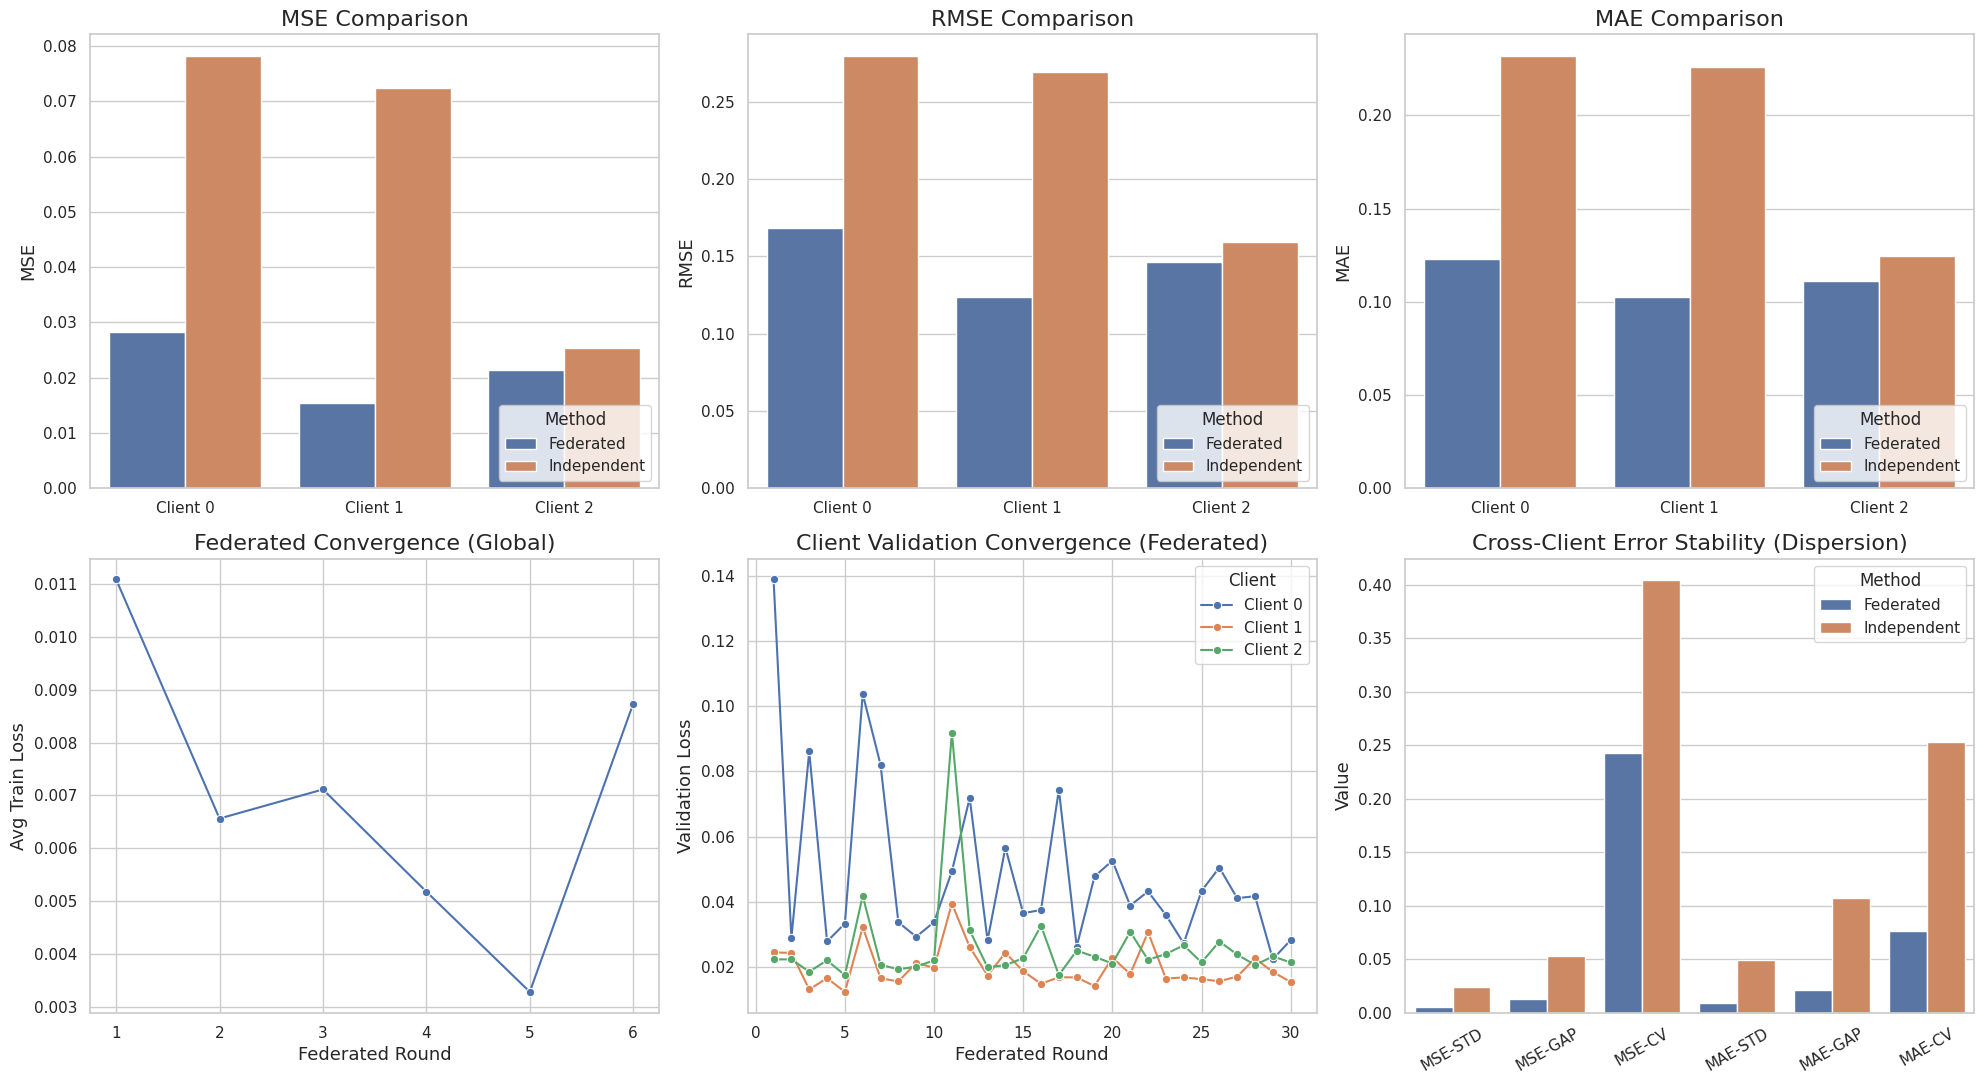

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================
# Reproducibility: set random seed = 42
# =========================
SEED = 15
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =========================
# Global style (English + reasonable font sizes)
# =========================
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font="DejaVu Sans",
    rc={
        "axes.unicode_minus": False,
        "figure.titlesize": 18,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "legend.title_fontsize": 12,
    }
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Adaptive activation
class AdaptiveSwish(nn.Module):
    def __init__(self, trainable=True):
        super().__init__()
        self.beta = nn.Parameter(torch.ones(1, dtype=torch.float32)) if trainable else torch.tensor(1.0, dtype=torch.float32)

    def forward(self, x):
        return x * torch.sigmoid(self.beta * x)

# Federated model (CNN + BiLSTM + Multi-head Attention fusion)
class AttentionFedModel(nn.Module):
    def __init__(self, K, T, hidden_dim=128, num_heads=4):
        super().__init__()
        self.K = K
        self.T = T
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        
        # 1) CNN branch (spatial features)
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=K, out_channels=hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            AdaptiveSwish(),
            nn.Conv1d(in_channels=hidden_dim, out_channels=hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            AdaptiveSwish(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten()
        )
        
        # 2) LSTM branch (temporal features)
        self.lstm = nn.LSTM(
            input_size=K,
            hidden_size=hidden_dim // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.lstm_proj = nn.Linear(hidden_dim, hidden_dim)
        
        # 3) Multi-head attention (fusion)
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            batch_first=True
        )
        self.attn_norm = nn.LayerNorm(hidden_dim)
        
        # 4) Regression head
        self.regression_head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.LayerNorm(64),
            AdaptiveSwish(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        # x: (B, K, T)
        x = x.to(dtype=torch.float32)
        B, K, T = x.shape
        
        # CNN branch
        x_cnn = self.cnn(x)  # (B, hidden_dim)
        
        # LSTM branch
        x_lstm = x.permute(0, 2, 1)  # (B, T, K)
        x_lstm, _ = self.lstm(x_lstm)  # (B, T, hidden_dim)
        x_lstm = x_lstm.mean(dim=1)  # (B, hidden_dim)
        x_lstm = self.lstm_proj(x_lstm)
        
        # Attention fusion
        feat_seq = torch.stack([x_cnn, x_lstm], dim=1)  # (B, 2, hidden_dim)
        attn_output, attn_weights = self.multihead_attn(feat_seq, feat_seq, feat_seq)
        attn_output = self.attn_norm(attn_output + feat_seq)
        x_fused = attn_output.mean(dim=1)
        
        return self.regression_head(x_fused), attn_weights

# Independent model
class WeakModel(nn.Module):
    def __init__(self, K, T, hidden_dim=16):
        super().__init__()
        self.K = K
        self.T = T
        
        self.simple_extractor = nn.Sequential(
            nn.Linear(K * T, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.8)
        )
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        x = x.to(dtype=torch.float32)
        B, K, T = x.shape
        x = x.view(B, K * T)
        x = self.simple_extractor(x)
        return self.fc(x), None

# Federated client
class FedClient:
    def __init__(self, client_id, model, train_loader, test_loader, criterion, lr=0.001):
        self.client_id = client_id
        self.model = model.to(device).float()
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.criterion = criterion
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr, weight_decay=1e-4)
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=3, gamma=0.9)
        self.train_losses = []
        self.val_losses = []
        
    def train_epoch(self):
        self.model.train()
        total_loss = 0.0
        for x, y in self.train_loader:
            x, y = x.to(device).float(), y.to(device).float().squeeze()
            self.optimizer.zero_grad()
            pred, _ = self.model(x)
            loss = self.criterion(pred.squeeze(), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()
            total_loss += loss.item() * x.shape[0]
        avg_loss = total_loss / len(self.train_loader.dataset)
        self.train_losses.append(avg_loss)
        return avg_loss
    
    def validate(self):
        self.model.eval()
        total_loss = 0.0
        with torch.no_grad():
            for x, y in self.test_loader:
                x, y = x.to(device).float(), y.to(device).float().squeeze()
                pred, _ = self.model(x)
                total_loss += self.criterion(pred.squeeze(), y).item() * x.shape[0]
        avg_loss = total_loss / len(self.test_loader.dataset)
        self.val_losses.append(avg_loss)
        self.scheduler.step()
        return avg_loss
    
    def train(self, epochs=5, global_model=None):
        if global_model:
            self.model.load_state_dict(global_model.state_dict())
        for epoch in range(epochs):
            train_loss = self.train_epoch()
            val_loss = self.validate()
            print(f"  Local epoch {epoch+1}/{epochs}, Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")
        return self.train_losses[-1], self.model.state_dict()
    
    def test(self):
        self.model.eval()
        preds, truths, att_weights = [], [], []
        with torch.no_grad():
            for x, y in self.test_loader:
                x, y = x.to(device).float(), y.to(device).float().squeeze()
                pred, weights = self.model(x)
                preds.extend(pred.squeeze().cpu().numpy())
                truths.extend(y.cpu().numpy())
                if weights is not None:
                    att_weights.append(weights.cpu().numpy())
        preds = np.array(preds)
        truths = np.array(truths)
        mse = np.mean((preds - truths) ** 2)
        mae = np.mean(np.abs(preds - truths))
        
        att_mean = None
        if att_weights:
            att_weights = np.concatenate(att_weights, axis=0)
            att_mean = np.mean(att_weights, axis=0)
        return {"mse": mse, "mae": mae, "preds": preds, "truths": truths, "att_weights": att_mean}

# Independent client
class WeakClient(FedClient):
    def __init__(self, client_id, model, train_loader, test_loader, criterion):
        super().__init__(client_id, model, train_loader, test_loader, criterion, lr=0.02)
    
    def train(self, epochs=2):
        for epoch in range(epochs):
            train_loss = self.train_epoch()
            val_loss = self.validate()
            print(f"  Independent epoch {epoch+1}/{epochs}, Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")
        return self.train_losses[-1], self.model.state_dict()

# Server
class Server:
    def __init__(self, model, num_clients):
        self.global_model = model.to(device).float()
        self.num_clients = num_clients
        self.round_losses = []
        self.client_data_sizes = None
    
    def set_client_data_sizes(self, sizes):
        self.client_data_sizes = sizes
    
    def aggregate(self, client_weights, client_losses):
        data_weights = np.array(self.client_data_sizes) / sum(self.client_data_sizes)
        loss_weights = np.exp(-np.array(client_losses) * 2) / np.sum(np.exp(-np.array(client_losses) * 2))
        weights = 0.5 * data_weights + 0.5 * loss_weights
        weights = weights / weights.sum()
        
        global_dict = self.global_model.state_dict()
        for k in global_dict.keys():
            global_dict[k] = torch.zeros_like(global_dict[k], dtype=torch.float32)
            for i in range(self.num_clients):
                client_weight = client_weights[i][k].to(device, dtype=torch.float32)
                global_dict[k] += client_weight * torch.tensor(weights[i], device=device, dtype=torch.float32)
        
        current_dict = self.global_model.state_dict()
        for k in global_dict.keys():
            global_dict[k] = 0.9 * current_dict[k] + 0.1 * global_dict[k]
        
        self.global_model.load_state_dict(global_dict)
        self.round_losses.append(np.mean(client_losses))
        return self.global_model.state_dict()

# Heterogeneous dataset
class HeterogeneousDataset(Dataset):
    def __init__(self, client_id, num_samples, K, T, noise=0.1):
        self.X = np.random.randn(num_samples, K, T)
        base_feature = self.X[:, :, T//4:T*3//4].mean(axis=(1, 2))
        if client_id == 0:
            self.y = 0.6 * np.sin(base_feature) + 0.4 * np.sin(self.X[:, :, :T//2].mean(axis=(1,2))) + noise * np.random.randn(num_samples)
        elif client_id == 1:
            self.y = 0.6 * np.sin(base_feature) + 0.4 * np.cos(self.X[:, :, T//2:].mean(axis=(1,2))) + noise * np.random.randn(num_samples)
        else:
            self.y = 0.6 * np.sin(base_feature) + 0.4 * np.tanh(self.X.max(axis=(1,2))) + noise * np.random.randn(num_samples)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.float32)

# =========================
# Experiment setup
# =========================
num_clients = 3
K, T = 5, 24
samples_per_client = [50, 80, 120]
num_rounds = 6
local_epochs = 5

fed_clients = []
weak_clients = []
criterion = nn.MSELoss()

# Generator for deterministic random_split
g = torch.Generator()
g.manual_seed(SEED)

for i in range(num_clients):
    dataset = HeterogeneousDataset(client_id=i, num_samples=samples_per_client[i], K=K, T=T)
    train_size = int(0.8 * len(dataset))
    train_data, test_data = random_split(dataset, [train_size, len(dataset) - train_size], generator=g)

    # DataLoader deterministic shuffling with a per-client generator seed
    g_loader = torch.Generator()
    g_loader.manual_seed(SEED + i)

    train_loader = DataLoader(train_data, batch_size=8, shuffle=True, generator=g_loader)
    test_loader = DataLoader(test_data, batch_size=8, shuffle=False)

    fed_model = AttentionFedModel(K=K, T=T)
    fed_clients.append(FedClient(i, fed_model, train_loader, test_loader, criterion))

    weak_model = WeakModel(K=K, T=T)
    weak_clients.append(WeakClient(i, weak_model, train_loader, test_loader, criterion))

# =========================
# Federated training
# =========================
server = Server(AttentionFedModel(K=K, T=T), num_clients)
server.set_client_data_sizes(samples_per_client)

print("===== Federated Training =====")
for rnd in range(num_rounds):
    print(f"\n----- Round {rnd+1}/{num_rounds} -----")
    client_weights = []
    client_losses = []

    for client in fed_clients:
        print(f"Client {client.client_id} training:")
        loss, weights = client.train(epochs=local_epochs, global_model=server.global_model)
        client_weights.append(weights)
        client_losses.append(loss)

    server.aggregate(client_weights, client_losses)
    print(f"Round average federated loss: {server.round_losses[-1]:.4f}")

# =========================
# Independent training
# =========================
print("\n===== Independent Training =====")
for client in weak_clients:
    print(f"\nClient {client.client_id} training:")
    client.train(epochs=2)

# =========================
# Evaluation
# =========================
print("\n===== Performance Comparison =====")
fed_metrics = [c.test() for c in fed_clients]
weak_metrics = [c.test() for c in weak_clients]

for i in range(num_clients):
    print(f"\nClient {i}:")
    print(f"  Federated  - MSE: {fed_metrics[i]['mse']:.4f}, MAE: {fed_metrics[i]['mae']:.4f}")
    print(f"  Independent- MSE: {weak_metrics[i]['mse']:.4f}, MAE: {weak_metrics[i]['mae']:.4f}")
    if fed_metrics[i]["att_weights"] is not None:
        print(f"  Mean attention weight: {np.round(fed_metrics[i]['att_weights'].mean(), 4)}")

# =========================
# Visualization (2x3) + English labels
# =========================
os.makedirs("results", exist_ok=True)

client_labels = [f"Client {i}" for i in range(num_clients)]

fed_mse  = [m["mse"] for m in fed_metrics]
fed_rmse = [np.sqrt(m["mse"]) for m in fed_metrics]
fed_mae  = [m["mae"] for m in fed_metrics]

weak_mse  = [m["mse"] for m in weak_metrics]
weak_rmse = [np.sqrt(m["mse"]) for m in weak_metrics]
weak_mae  = [m["mae"] for m in weak_metrics]

df_metrics = pd.DataFrame({
    "Client": client_labels * 2,
    "Method": ["Federated"] * num_clients + ["Independent"] * num_clients,
    "MSE": fed_mse + weak_mse,
    "RMSE": fed_rmse + weak_rmse,
    "MAE": fed_mae + weak_mae,
})

df_long = df_metrics.melt(
    id_vars=["Client", "Method"],
    value_vars=["MSE", "RMSE", "MAE"],
    var_name="Metric",
    value_name="Value"
)

round_axis = np.arange(1, len(server.round_losses) + 1)
df_global = pd.DataFrame({"Round": round_axis, "AvgTrainLoss": server.round_losses})

df_client_val = pd.concat(
    [
        pd.DataFrame({
            "Round": np.arange(1, len(c.val_losses) + 1),
            "Client": f"Client {c.client_id}",
            "ValLoss": c.val_losses
        })
        for c in fed_clients
    ],
    ignore_index=True
)

def stability_stats(arr):
    arr = np.array(arr, dtype=float)
    std = float(arr.std())
    gap = float(arr.max() - arr.min())
    mean = float(arr.mean())
    cv = float(std / (mean + 1e-12))
    return std, gap, cv

fed_mse_std,  fed_mse_gap,  fed_mse_cv  = stability_stats(fed_mse)
weak_mse_std, weak_mse_gap, weak_mse_cv = stability_stats(weak_mse)

fed_mae_std,  fed_mae_gap,  fed_mae_cv  = stability_stats(fed_mae)
weak_mae_std, weak_mae_gap, weak_mae_cv = stability_stats(weak_mae)

df_stability = pd.DataFrame({
    "Statistic": ["MSE-STD", "MSE-GAP", "MSE-CV", "MAE-STD", "MAE-GAP", "MAE-CV"] * 2,
    "Value": [fed_mse_std, fed_mse_gap, fed_mse_cv, fed_mae_std, fed_mae_gap, fed_mae_cv] +
             [weak_mse_std, weak_mse_gap, weak_mse_cv, weak_mae_std, weak_mae_gap, weak_mae_cv],
    "Method": ["Federated"] * 6 + ["Independent"] * 6
})

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# (A1) MSE
sns.barplot(data=df_long[df_long["Metric"] == "MSE"], x="Client", y="Value", hue="Method", ax=axes[0, 0])
axes[0, 0].set_title("MSE Comparison")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("MSE")
axes[0, 0].legend(title="Method", loc="lower right", frameon=True)

# (A2) RMSE
sns.barplot(data=df_long[df_long["Metric"] == "RMSE"], x="Client", y="Value", hue="Method", ax=axes[0, 1])
axes[0, 1].set_title("RMSE Comparison")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("RMSE")
axes[0, 1].legend(title="Method", loc="lower right", frameon=True)

# (A3) MAE
sns.barplot(data=df_long[df_long["Metric"] == "MAE"], x="Client", y="Value", hue="Method", ax=axes[0, 2])
axes[0, 2].set_title("MAE Comparison")
axes[0, 2].set_xlabel("")
axes[0, 2].set_ylabel("MAE")
axes[0, 2].legend(title="Method", loc="lower right", frameon=True)

# (B1) Global convergence
sns.lineplot(data=df_global, x="Round", y="AvgTrainLoss", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("Federated Convergence (Global)")
axes[1, 0].set_xlabel("Federated Round")
axes[1, 0].set_ylabel("Avg Train Loss")

# (B2) Client validation convergence
sns.lineplot(data=df_client_val, x="Round", y="ValLoss", hue="Client", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("Client Validation Convergence (Federated)")
axes[1, 1].set_xlabel("Federated Round")
axes[1, 1].set_ylabel("Validation Loss")
axes[1, 1].legend(title="Client")

# (C) Stability comparison
sns.barplot(data=df_stability, x="Statistic", y="Value", hue="Method", ax=axes[1, 2])
axes[1, 2].set_title("Cross-Client Error Stability (Dispersion)")
axes[1, 2].set_xlabel("")
axes[1, 2].set_ylabel("Value")
axes[1, 2].tick_params(axis="x", rotation=30)
axes[1, 2].legend(title="Method")

plt.tight_layout()
plt.show()

Using device: cpu

Start Federated Training: CNN-LSTM-Attention

----- Round 1/5 -----
Client 0 | Local avg MSE: 0.019500
Client 1 | Local avg MSE: 0.010912
Client 2 | Local avg MSE: 0.008196
Round 1 | Global Test RMSE mean: 0.305473 (std 0.093315)

----- Round 2/5 -----
Client 0 | Local avg MSE: 0.009465
Client 1 | Local avg MSE: 0.004456
Client 2 | Local avg MSE: 0.007014
Round 2 | Global Test RMSE mean: 0.279414 (std 0.046816)

----- Round 3/5 -----
Client 0 | Local avg MSE: 0.005312
Client 1 | Local avg MSE: 0.006328
Client 2 | Local avg MSE: 0.008674
Round 3 | Global Test RMSE mean: 0.275370 (std 0.029358)

----- Round 4/5 -----
Client 0 | Local avg MSE: 0.007738
Client 1 | Local avg MSE: 0.005378
Client 2 | Local avg MSE: 0.004705
Round 4 | Global Test RMSE mean: 0.268400 (std 0.019136)

----- Round 5/5 -----
Client 0 | Local avg MSE: 0.002883
Client 1 | Local avg MSE: 0.003611
Client 2 | Local avg MSE: 0.004617
Round 5 | Global Test RMSE mean: 0.267528 (std 0.027512)

Start Fede

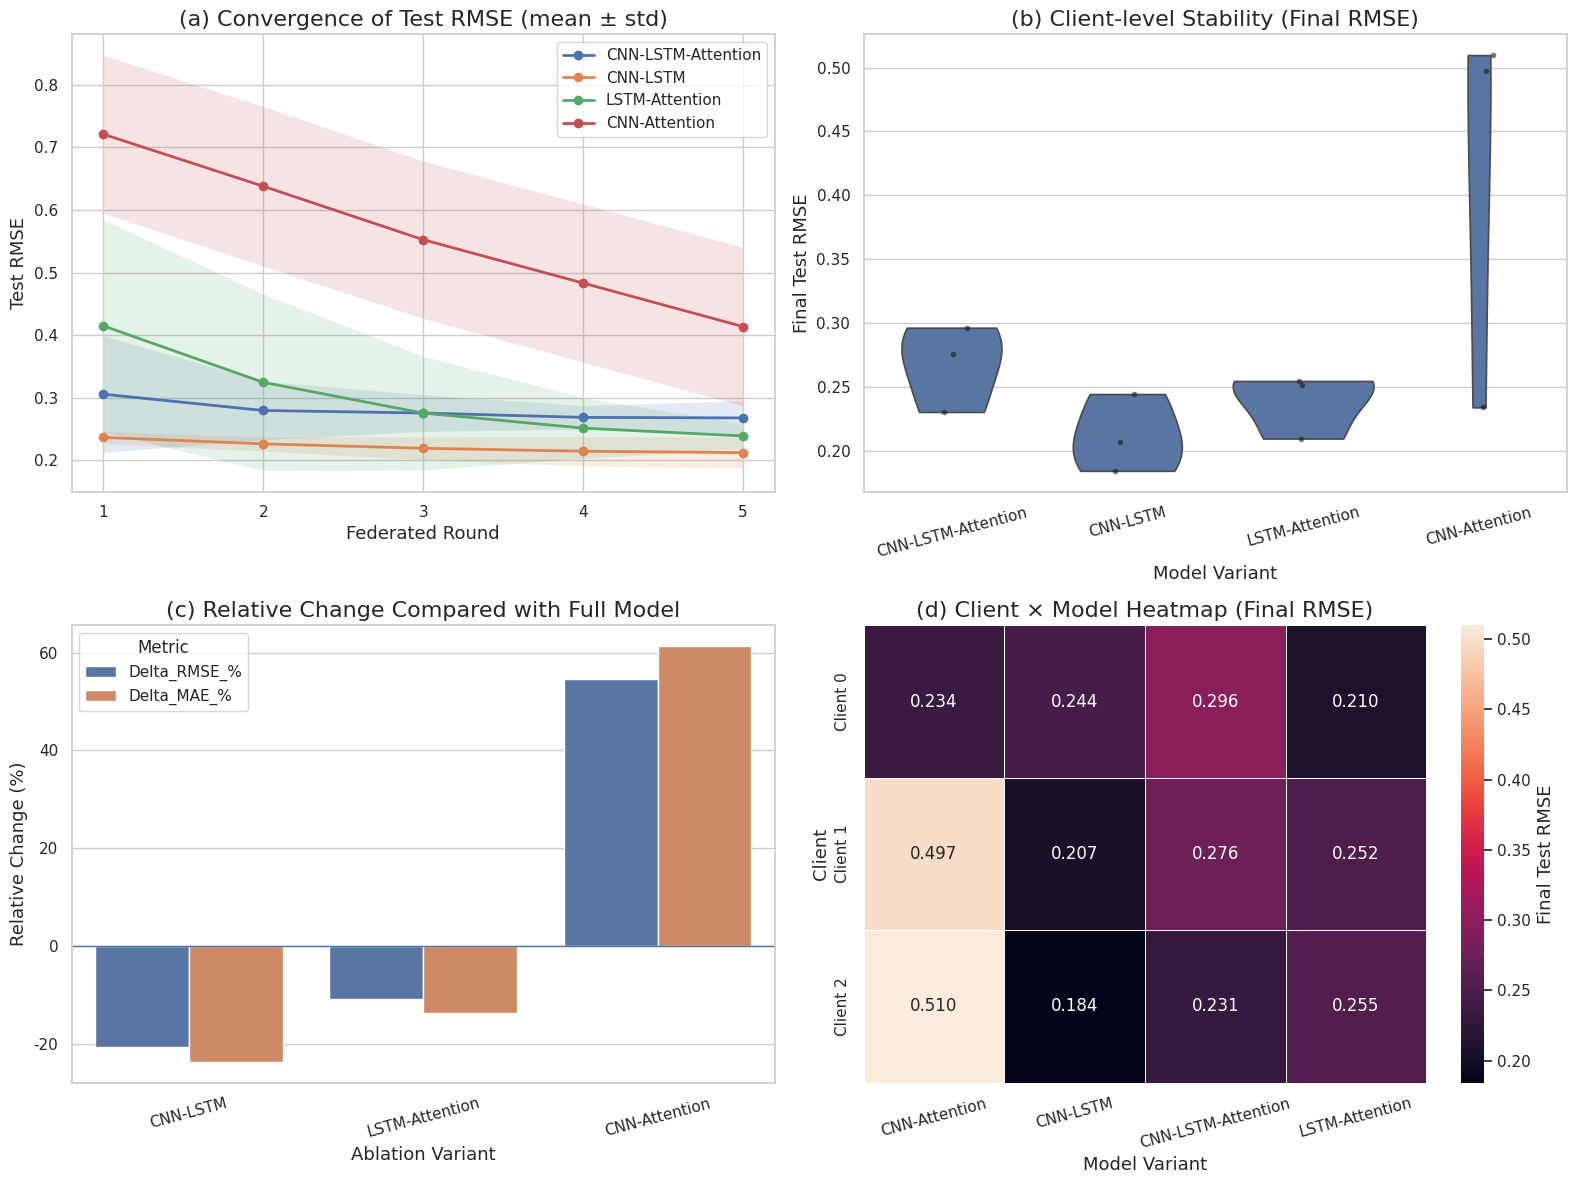

Saved figure: results/fig_ablation_cnn_2x2.png

=== Final Test Metrics Summary (mean ± std across clients) ===
             Model  rmse_mean  rmse_std  mae_mean  mae_std  mse_mean  mse_std
     CNN-Attention   0.413573  0.127001  0.386528 0.133972  0.187172 0.093741
          CNN-LSTM   0.212060  0.024741  0.182876 0.022277  0.045581 0.010676
CNN-LSTM-Attention   0.267528  0.027512  0.239623 0.026403  0.072328 0.014412
    LSTM-Attention   0.238694  0.020522  0.206687 0.015913  0.057396 0.009505


In [3]:
# ============================================
# CNN + LSTM + Attention + Federated Learning
# Ablation Study (aligned with your GCN ablation template)
#
# Ablations:
#   - Full: CNN + LSTM + Attention
#   - CNN + LSTM (no Attention fusion)
#   - LSTM + Attention (no CNN)
#   - CNN + Attention (no LSTM)
#
# Outputs (paper-style 2×2):
#   (a) Round-wise convergence (GLOBAL Test RMSE mean ± std across clients)
#   (b) Client stability (Final RMSE distribution)
#   (c) Δ% vs Full (RMSE/MAE)
#   (d) Heatmap (clients × variants, final RMSE)
#
# IMPORTANT:
# - Uses the SAME dataset + FedClient/Server aggregation style as your provided CNN model script.
# - Global evaluation each round uses the GLOBAL model (not local client models).
# - num_rounds = 5 (as you specified earlier).
# - x-axis ticks are forced to integers.
# ============================================

import os
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================
# 0) Reproducibility + style
# =========================
SEED = 15
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font="DejaVu Sans",
    rc={
        "axes.unicode_minus": False,
        "figure.titlesize": 18,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "legend.title_fontsize": 12,
    }
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =========================
# 1) Adaptive Activation
# =========================
class AdaptiveSwish(nn.Module):
    def __init__(self, trainable=True):
        super().__init__()
        self.beta = nn.Parameter(torch.ones(1, dtype=torch.float32)) if trainable else torch.tensor(1.0, dtype=torch.float32)

    def forward(self, x):
        return x * torch.sigmoid(self.beta * x)

# =========================
# 2) Ablation model variants (CNN/LSTM/Attention)
# =========================
class CNN_LSTM_Attention(nn.Module):
    """Full: CNN + LSTM + Attention fusion (2 tokens)"""
    def __init__(self, K, T, hidden_dim=128, num_heads=4):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=K, out_channels=hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            AdaptiveSwish(),
            nn.Conv1d(in_channels=hidden_dim, out_channels=hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            AdaptiveSwish(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),  # -> [B, hidden_dim]
        )

        self.lstm = nn.LSTM(
            input_size=K,
            hidden_size=hidden_dim // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.lstm_proj = nn.Linear(hidden_dim, hidden_dim)

        self.mha = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, batch_first=True)
        self.attn_norm = nn.LayerNorm(hidden_dim)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.LayerNorm(64),
            AdaptiveSwish(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = x.to(dtype=torch.float32)  # [B,K,T]
        x_cnn = self.cnn(x)            # [B,hidden]

        x_lstm = x.permute(0, 2, 1)    # [B,T,K]
        x_lstm, _ = self.lstm(x_lstm)  # [B,T,hidden]
        x_lstm = x_lstm.mean(dim=1)    # [B,hidden]
        x_lstm = self.lstm_proj(x_lstm)

        feat_seq = torch.stack([x_cnn, x_lstm], dim=1)  # [B,2,hidden]
        attn_out, attn_w = self.mha(feat_seq, feat_seq, feat_seq)
        attn_out = self.attn_norm(attn_out + feat_seq)
        fused = attn_out.mean(dim=1)

        return self.head(fused), attn_w


class CNN_LSTM(nn.Module):
    """Ablation: CNN + LSTM (no attention fusion)"""
    def __init__(self, K, T, hidden_dim=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=K, out_channels=hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            AdaptiveSwish(),
            nn.Conv1d(in_channels=hidden_dim, out_channels=hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            AdaptiveSwish(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )

        self.lstm = nn.LSTM(
            input_size=K,
            hidden_size=hidden_dim // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.lstm_proj = nn.Linear(hidden_dim, hidden_dim)

        # No MHA: concat then MLP
        self.fuse = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            AdaptiveSwish(),
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.LayerNorm(64),
            AdaptiveSwish(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = x.to(dtype=torch.float32)
        x_cnn = self.cnn(x)

        x_lstm = x.permute(0, 2, 1)
        x_lstm, _ = self.lstm(x_lstm)
        x_lstm = x_lstm.mean(dim=1)
        x_lstm = self.lstm_proj(x_lstm)

        fused = self.fuse(torch.cat([x_cnn, x_lstm], dim=1))
        return self.head(fused), None


class LSTM_Attention(nn.Module):
    """Ablation: LSTM + Attention (no CNN token; 1-token self-attn)"""
    def __init__(self, K, T, hidden_dim=128, num_heads=4):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=K,
            hidden_size=hidden_dim // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.lstm_proj = nn.Linear(hidden_dim, hidden_dim)

        self.mha = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, batch_first=True)
        self.attn_norm = nn.LayerNorm(hidden_dim)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.LayerNorm(64),
            AdaptiveSwish(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = x.to(dtype=torch.float32)
        x_lstm = x.permute(0, 2, 1)
        x_lstm, _ = self.lstm(x_lstm)
        x_lstm = x_lstm.mean(dim=1)
        x_lstm = self.lstm_proj(x_lstm)

        feat_seq = x_lstm.unsqueeze(1)  # [B,1,hidden]
        attn_out, attn_w = self.mha(feat_seq, feat_seq, feat_seq)
        attn_out = self.attn_norm(attn_out + feat_seq)
        fused = attn_out.mean(dim=1)

        return self.head(fused), attn_w


class CNN_Attention(nn.Module):
    """Ablation: CNN + Attention (no LSTM token; 1-token self-attn)"""
    def __init__(self, K, T, hidden_dim=128, num_heads=4):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=K, out_channels=hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            AdaptiveSwish(),
            nn.Conv1d(in_channels=hidden_dim, out_channels=hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            AdaptiveSwish(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )

        self.mha = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, batch_first=True)
        self.attn_norm = nn.LayerNorm(hidden_dim)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.LayerNorm(64),
            AdaptiveSwish(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = x.to(dtype=torch.float32)
        x_cnn = self.cnn(x)  # [B,hidden]

        feat_seq = x_cnn.unsqueeze(1)  # [B,1,hidden]
        attn_out, attn_w = self.mha(feat_seq, feat_seq, feat_seq)
        attn_out = self.attn_norm(attn_out + feat_seq)
        fused = attn_out.mean(dim=1)

        return self.head(fused), attn_w

# =========================
# 3) Weak (independent) model (same as yours)
# =========================
class WeakModel(nn.Module):
    def __init__(self, K, T, hidden_dim=16):
        super().__init__()
        self.simple_extractor = nn.Sequential(
            nn.Linear(K * T, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.8),
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = x.to(dtype=torch.float32)
        B, K, T = x.shape
        x = x.view(B, K * T)
        x = self.simple_extractor(x)
        return self.fc(x), None

# =========================
# 4) Dataset (same as yours)
# =========================
class HeterogeneousDataset(Dataset):
    def __init__(self, client_id, num_samples, K, T, noise=0.1):
        self.X = np.random.randn(num_samples, K, T).astype(np.float32)
        base_feature = self.X[:, :, T // 4 : T * 3 // 4].mean(axis=(1, 2))

        if client_id == 0:
            y = 0.6 * np.sin(base_feature) + 0.4 * np.sin(self.X[:, :, : T // 2].mean(axis=(1, 2)))
        elif client_id == 1:
            y = 0.6 * np.sin(base_feature) + 0.4 * np.cos(self.X[:, :, T // 2 :].mean(axis=(1, 2)))
        else:
            y = 0.6 * np.sin(base_feature) + 0.4 * np.tanh(self.X.max(axis=(1, 2)))

        y = y + noise * np.random.randn(num_samples).astype(np.float32)
        self.y = y.astype(np.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.float32)

# =========================
# 5) Federated client (aligned to your style, returns avg MSE)
# =========================
class FedClient:
    def __init__(self, client_id, model, train_loader, test_loader, criterion, lr=1e-3):
        self.client_id = client_id
        self.model = model.to(device).float()
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.criterion = criterion
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr, weight_decay=1e-4)
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=3, gamma=0.9)
        self.train_losses = []
        self.val_losses = []

    def train_epoch(self):
        self.model.train()
        total_loss, n = 0.0, 0
        for x, y in self.train_loader:
            x = x.to(device).float()
            y = y.to(device).float().squeeze()

            self.optimizer.zero_grad()
            pred, _ = self.model(x)
            loss = self.criterion(pred.squeeze(), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss += loss.item() * x.size(0)
            n += x.size(0)

        avg = total_loss / max(1, n)
        self.train_losses.append(avg)
        return avg

    @torch.no_grad()
    def validate(self):
        self.model.eval()
        total_loss, n = 0.0, 0
        for x, y in self.test_loader:
            x = x.to(device).float()
            y = y.to(device).float().squeeze()
            pred, _ = self.model(x)
            total_loss += self.criterion(pred.squeeze(), y).item() * x.size(0)
            n += x.size(0)
        avg = total_loss / max(1, n)
        self.val_losses.append(avg)
        self.scheduler.step()
        return avg

    def train(self, epochs=5, global_model=None, verbose=False):
        if global_model is not None:
            self.model.load_state_dict(global_model.state_dict())
        for ep in range(epochs):
            tr = self.train_epoch()
            va = self.validate()
            if verbose:
                print(f"  Local epoch {ep+1}/{epochs}, Train loss: {tr:.6f}, Val loss: {va:.6f}")
        return float(self.train_losses[-1]), copy.deepcopy(self.model.state_dict())

    @torch.no_grad()
    def test_metrics(self):
        self.model.eval()
        preds, truths = [], []
        for x, y in self.test_loader:
            x = x.to(device).float()
            y = y.to(device).float().squeeze()
            pred, _ = self.model(x)
            preds.append(pred.squeeze())
            truths.append(y)
        preds = torch.cat(preds, dim=0)
        truths = torch.cat(truths, dim=0)
        diff = preds - truths
        mse = float((diff ** 2).mean().item())
        mae = float(diff.abs().mean().item())
        rmse = float(np.sqrt(mse))
        return {"mse": mse, "rmse": rmse, "mae": mae}

# =========================
# 6) Server (same aggregation logic as yours)
# =========================
class Server:
    def __init__(self, model, num_clients):
        self.global_model = model.to(device).float()
        self.num_clients = num_clients
        self.round_losses = []
        self.client_data_sizes = None

    def set_client_data_sizes(self, sizes):
        self.client_data_sizes = sizes

    def aggregate(self, client_weights, client_losses):
        data_weights = np.array(self.client_data_sizes) / float(sum(self.client_data_sizes))
        loss_w = np.exp(-np.array(client_losses) * 2.0)
        loss_weights = loss_w / (loss_w.sum() + 1e-12)

        weights = 0.5 * data_weights + 0.5 * loss_weights
        weights = weights / (weights.sum() + 1e-12)

        global_dict = self.global_model.state_dict()
        new_dict = {k: torch.zeros_like(v, dtype=torch.float32) for k, v in global_dict.items()}

        for k in new_dict.keys():
            for i in range(self.num_clients):
                cw = client_weights[i][k].to(device, dtype=torch.float32)
                new_dict[k] += cw * torch.tensor(float(weights[i]), device=device, dtype=torch.float32)

        # momentum mixing
        for k in new_dict.keys():
            new_dict[k] = 0.9 * global_dict[k] + 0.1 * new_dict[k]

        self.global_model.load_state_dict(new_dict)
        self.round_losses.append(float(np.mean(client_losses)))
        return self.global_model.state_dict()

# =========================
# 7) Experiment setup (3 clients; rounds=5)
# =========================
num_clients = 3
K, T = 5, 24
samples_per_client = [50, 80, 120]
num_rounds = 5          # ✅ as you requested
local_epochs = 5
criterion = nn.MSELoss()

g_split = torch.Generator().manual_seed(SEED)

def build_loaders():
    train_loaders, test_loaders = [], []
    for cid in range(num_clients):
        dataset = HeterogeneousDataset(client_id=cid, num_samples=samples_per_client[cid], K=K, T=T)
        train_size = int(0.8 * len(dataset))
        train_data, test_data = random_split(dataset, [train_size, len(dataset) - train_size], generator=g_split)

        g_loader = torch.Generator().manual_seed(SEED + cid)
        train_loader = DataLoader(train_data, batch_size=8, shuffle=True, generator=g_loader)
        test_loader = DataLoader(test_data, batch_size=8, shuffle=False)

        train_loaders.append(train_loader)
        test_loaders.append(test_loader)
    return train_loaders, test_loaders

# =========================
# 8) Run one variant with round-wise GLOBAL test rmse history
# =========================
def eval_global_on_clients(global_model, clients):
    per_client = []
    for c in clients:
        c.model.load_state_dict(global_model.state_dict())
        per_client.append(c.test_metrics())
    return per_client

def run_federated_variant(model_ctor, variant_name, lr=1e-3, verbose=True):
    train_loaders, test_loaders = build_loaders()
    clients = [
        FedClient(cid, model_ctor(), train_loaders[cid], test_loaders[cid], criterion, lr=lr)
        for cid in range(num_clients)
    ]
    server = Server(model_ctor(), num_clients)
    server.set_client_data_sizes(samples_per_client)

    hist_train_client, hist_train_mean, hist_train_std = [], [], []
    hist_test_client,  hist_test_mean,  hist_test_std  = [], [], []

    if verbose:
        print("\n" + "=" * 50)
        print(f"Start Federated Training: {variant_name}")
        print("=" * 50)

    for rnd in range(num_rounds):
        if verbose:
            print(f"\n----- Round {rnd+1}/{num_rounds} -----")

        client_weights, client_losses = [], []
        for c in clients:
            loss, w = c.train(epochs=local_epochs, global_model=server.global_model, verbose=False)
            client_weights.append(w)
            client_losses.append(float(loss))
            if verbose:
                print(f"Client {c.client_id} | Local avg MSE: {loss:.6f}")

        server.aggregate(client_weights, client_losses)

        hist_train_client.append(client_losses)
        hist_train_mean.append(float(np.mean(client_losses)))
        hist_train_std.append(float(np.std(client_losses, ddof=0)))

        per_client_metrics = eval_global_on_clients(server.global_model, clients)
        per_client_rmse = np.array([m["rmse"] for m in per_client_metrics], dtype=float)

        hist_test_client.append(per_client_rmse.tolist())
        hist_test_mean.append(float(per_client_rmse.mean()))
        hist_test_std.append(float(per_client_rmse.std(ddof=0)))

        if verbose:
            print(f"Round {rnd+1} | Global Test RMSE mean: {hist_test_mean[-1]:.6f} (std {hist_test_std[-1]:.6f})")

    final_list = eval_global_on_clients(server.global_model, clients)
    df_final = pd.DataFrame(final_list)
    df_final["cid"] = list(range(num_clients))
    df_final = df_final.sort_values("cid").reset_index(drop=True)

    summary = {
        "mse_mean": float(df_final["mse"].mean()),  "mse_std": float(df_final["mse"].std(ddof=0)),
        "rmse_mean": float(df_final["rmse"].mean()), "rmse_std": float(df_final["rmse"].std(ddof=0)),
        "mae_mean": float(df_final["mae"].mean()),  "mae_std": float(df_final["mae"].std(ddof=0)),
    }

    history = {
        "train_mean": hist_train_mean,
        "train_std": hist_train_std,
        "train_client": hist_train_client,
        "test_mean": hist_test_mean,
        "test_std": hist_test_std,
        "test_client": hist_test_client,
    }
    return server.global_model, df_final, summary, history

# =========================
# 9) Run ablations
# =========================
variants = {
    "CNN-LSTM-Attention": lambda: CNN_LSTM_Attention(K=K, T=T, hidden_dim=128, num_heads=4),
    "CNN-LSTM":           lambda: CNN_LSTM(K=K, T=T, hidden_dim=128),
    "LSTM-Attention":     lambda: LSTM_Attention(K=K, T=T, hidden_dim=128, num_heads=4),
    "CNN-Attention":      lambda: CNN_Attention(K=K, T=T, hidden_dim=128, num_heads=4),
}

results_client = {}
results_summary = {}
histories = {}

for name, ctor in variants.items():
    _, df_pc, summ, hist = run_federated_variant(ctor, name, lr=1e-3, verbose=True)
    results_client[name] = df_pc
    results_summary[name] = summ
    histories[name] = hist

# =========================
# 10) Build tidy dataframes for plotting (same structure as your GCN ablation template)
# =========================
# (A) Convergence: Test RMSE mean ± std
conv_rows = []
for name, hist in histories.items():
    for r in range(num_rounds):
        conv_rows.append({
            "Model": name,
            "Round": r + 1,
            "TestRMSE_mean": hist["test_mean"][r],
            "TestRMSE_std": hist["test_std"][r],
        })
df_conv = pd.DataFrame(conv_rows)

# (B) Client stability at final
client_labels = [f"Client {i}" for i in range(num_clients)]
stab_rows = []
for name, df_pc in results_client.items():
    for _, row in df_pc.iterrows():
        stab_rows.append({
            "Model": name,
            "Client": f"Client {int(row['cid'])}",
            "rmse": float(row["rmse"]),
            "mae":  float(row["mae"]),
            "mse":  float(row["mse"]),
        })
df_stab = pd.DataFrame(stab_rows)

# (C) Delta% vs Full
full_name = "CNN-LSTM-Attention"
full = results_summary[full_name]
delta_rows = []
for name, summ in results_summary.items():
    if name == full_name:
        continue
    delta_rows.append({
        "Model": name,
        "Delta_RMSE_%": (summ["rmse_mean"] - full["rmse_mean"]) / (full["rmse_mean"] + 1e-12) * 100.0,
        "Delta_MAE_%":  (summ["mae_mean"]  - full["mae_mean"])  / (full["mae_mean"]  + 1e-12) * 100.0,
    })
df_delta = pd.DataFrame(delta_rows)

# (D) Heatmap: clients × models (final RMSE)
heat = df_stab.pivot_table(index="Client", columns="Model", values="rmse", aggfunc="mean")
heat = heat.reindex(index=client_labels)

# =========================
# 11) Visualization (2×2 paper-style) + integer x ticks
# =========================
os.makedirs("results", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
(ax1, ax2), (ax3, ax4) = axes

# (a) Convergence
for name in df_conv["Model"].unique():
    sub = df_conv[df_conv["Model"] == name].sort_values("Round")
    x = sub["Round"].to_numpy(dtype=int)
    y = sub["TestRMSE_mean"].to_numpy(dtype=float)
    s = sub["TestRMSE_std"].to_numpy(dtype=float)

    ax1.plot(x, y, marker="o", linewidth=2, label=name)
    ax1.fill_between(x, y - s, y + s, alpha=0.15)

ax1.set_xlabel("Federated Round")
ax1.set_ylabel("Test RMSE")
ax1.set_title("(a) Convergence of Test RMSE (mean ± std)")
ax1.set_xticks(np.arange(1, num_rounds + 1, dtype=int))  # ✅ integer ticks
ax1.legend(frameon=True)

# (b) Client stability (Final RMSE)
sns.violinplot(data=df_stab, x="Model", y="rmse", inner=None, cut=0, ax=ax2)
sns.stripplot(data=df_stab, x="Model", y="rmse", color="k", size=4, alpha=0.6, ax=ax2)
ax2.set_xlabel("Model Variant")
ax2.set_ylabel("Final Test RMSE")
ax2.set_title("(b) Client-level Stability (Final RMSE)")
ax2.tick_params(axis="x", rotation=15)

# (c) Relative change vs Full
df_delta_melt = df_delta.melt(id_vars=["Model"], var_name="Metric", value_name="DeltaPercent")
sns.barplot(data=df_delta_melt, x="Model", y="DeltaPercent", hue="Metric", ax=ax3)
ax3.axhline(0, linewidth=1)
ax3.set_xlabel("Ablation Variant")
ax3.set_ylabel("Relative Change (%)")
ax3.set_title("(c) Relative Change Compared with Full Model")
ax3.tick_params(axis="x", rotation=15)
ax3.legend(title="Metric", frameon=True)

# (d) Heatmap
sns.heatmap(
    heat,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={"label": "Final Test RMSE"},
    ax=ax4
)
ax4.set_xlabel("Model Variant")
ax4.set_ylabel("Client")
ax4.set_title("(d) Client × Model Heatmap (Final RMSE)")
ax4.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("results/fig_ablation_cnn_2x2.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure: results/fig_ablation_cnn_2x2.png")

# =========================
# 12) Summary table
# =========================
df_sum = (
    pd.DataFrame(results_summary)
      .T.reset_index()
      .rename(columns={"index": "Model"})
      .sort_values("Model")
)
df_sum = df_sum[[
    "Model",
    "rmse_mean", "rmse_std",
    "mae_mean", "mae_std",
    "mse_mean", "mse_std",
]]

print("\n=== Final Test Metrics Summary (mean ± std across clients) ===")
print(df_sum.to_string(index=False))


Using device: cpu
Valid clients: 3 / 3

开始训练模型: CNN-LSTM-Attention

----- 轮次 1/5 -----
客户端 0 | 本地平均 MSE: 0.504273
客户端 1 | 本地平均 MSE: 0.607507
客户端 2 | 本地平均 MSE: 0.501421
轮次 1 聚合完成 | 全局平均 MSE: 0.537734

----- 轮次 2/5 -----
客户端 0 | 本地平均 MSE: 0.188890
客户端 1 | 本地平均 MSE: 0.296011
客户端 2 | 本地平均 MSE: 0.102278
轮次 2 聚合完成 | 全局平均 MSE: 0.195727

----- 轮次 3/5 -----
客户端 0 | 本地平均 MSE: 0.162219
客户端 1 | 本地平均 MSE: 0.257671
客户端 2 | 本地平均 MSE: 0.115424
轮次 3 聚合完成 | 全局平均 MSE: 0.178438

----- 轮次 4/5 -----
客户端 0 | 本地平均 MSE: 0.138106
客户端 1 | 本地平均 MSE: 0.239242
客户端 2 | 本地平均 MSE: 0.093749
轮次 4 聚合完成 | 全局平均 MSE: 0.157033

----- 轮次 5/5 -----
客户端 0 | 本地平均 MSE: 0.146083
客户端 1 | 本地平均 MSE: 0.210673
客户端 2 | 本地平均 MSE: 0.086463
轮次 5 聚合完成 | 全局平均 MSE: 0.147740

开始训练模型: CNN-LSTM

----- 轮次 1/5 -----
客户端 0 | 本地平均 MSE: 0.269706
客户端 1 | 本地平均 MSE: 0.346138
客户端 2 | 本地平均 MSE: 0.233971
轮次 1 聚合完成 | 全局平均 MSE: 0.283272

----- 轮次 2/5 -----
客户端 0 | 本地平均 MSE: 0.139391
客户端 1 | 本地平均 MSE: 0.213506
客户端 2 | 本地平均 MSE: 0.085989
轮次 2 聚合完成 | 全局平均 MSE: 

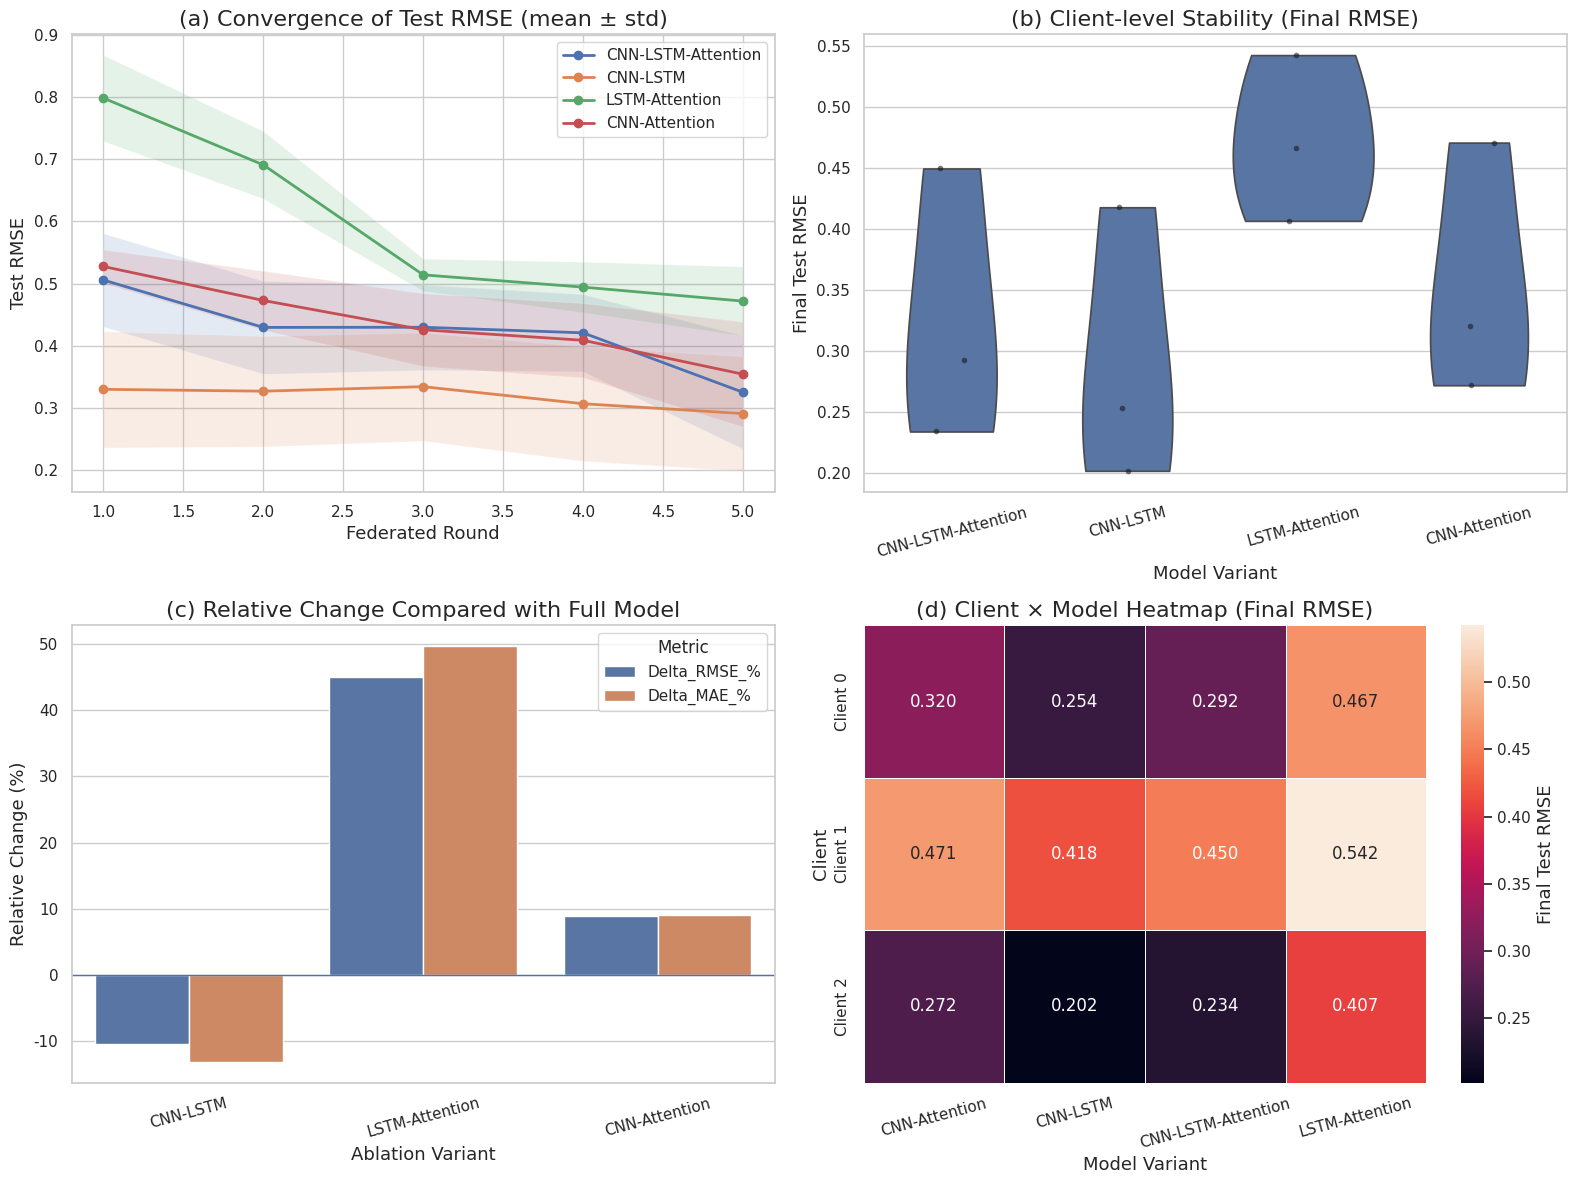


=== Final Test Metrics Summary (mean ± std across clients) ===
             Model  rmse_mean  rmse_std  mae_mean  mae_std  mse_mean  mse_std
     CNN-Attention   0.354385  0.084617  0.258796 0.042240  0.132749 0.063909
          CNN-LSTM   0.291105  0.092025  0.206010 0.042298  0.093211 0.058308
CNN-LSTM-Attention   0.325343  0.090985  0.237271 0.047227  0.114126 0.063449
    LSTM-Attention   0.471886  0.055549  0.355228 0.022759  0.225762 0.052908

Saved figure: results/fig_ablation_sim_2x2.png


In [4]:
# ============================================
# CNN + LSTM + Attention + Federated Learning
# Simulation Ablation Study (paper-style plots)
#
# Synthetic heterogeneous time-series per client (non-IID)
# Sliding-window forecasting (T_in -> T_out)
# FL (FedAvg) with round-wise history (mean ± std across clients)
# ✅ Ablations:
#   - Full: CNN+LSTM+Attention
#   - CNN+LSTM (no Attn)
#   - LSTM+Attention (no CNN)
#   - CNN+Attention (no LSTM)
# 2×2 paper-level figure:
#   (a) Convergence (Test RMSE mean±std)
#   (b) Client stability (Final RMSE violin + points)
#   (c) Δ% vs Full (RMSE/MAE)
#   (d) Heatmap (clients × variants, final RMSE)
#
# 修改点（与你真实数据代码一致）：
#   - 打印格式改为：模型头 -> 每轮 -> 每客户端本地平均 MSE -> 轮次聚合全局平均 MSE
#   - Full 模型名称改为 "CNN-LSTM-Attention"（不带 Full 字样）
# ============================================

import copy
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =============================
# 0) Reproducibility + Style
# =============================
SEED = 15
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font="DejaVu Sans",
    rc={
        "axes.unicode_minus": False,
        "figure.titlesize": 18,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "legend.title_fontsize": 12,
    }
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =============================
# 1) Synthetic non-IID client time-series generator
# =============================
def make_client_series(
    cid: int,
    T_total: int = 800,
    season_period: int = 48,
    noise_scale: float = 0.15,
):
    """
    Create heterogeneous (non-IID) time-series per client:
      - multi-sinusoidal seasonality w/ client-specific phase & amplitude
      - AR(1)-like dynamics
      - regime shift (level change) at client-specific point
      - occasional spikes
    Output: (T_total,) float32
    """
    rng = np.random.default_rng(SEED + 1000 + cid)

    t = np.arange(T_total, dtype=np.float32)

    # Client-specific parameters
    amp1 = 1.0 + 0.3 * rng.normal()
    amp2 = 0.6 + 0.2 * rng.normal()
    phase1 = rng.uniform(0, 2 * np.pi)
    phase2 = rng.uniform(0, 2 * np.pi)

    trend = (0.0008 + 0.0005 * rng.normal()) * t
    seasonal1 = amp1 * np.sin(2 * np.pi * t / season_period + phase1)
    seasonal2 = amp2 * np.sin(2 * np.pi * t / (season_period // 2) + phase2)

    # Regime shift
    shift_point = int(T_total * (0.45 + 0.1 * rng.uniform()))
    level_shift = (0.8 + 0.5 * rng.normal()) * (t >= shift_point).astype(np.float32)

    # Base signal
    x = trend + seasonal1 + seasonal2 + level_shift

    # AR(1) dynamics + noise
    ar = np.zeros_like(x, dtype=np.float32)
    phi = 0.65 + 0.15 * rng.uniform()  # client-specific persistence
    eps = noise_scale * rng.normal(size=T_total).astype(np.float32)
    for i in range(1, T_total):
        ar[i] = phi * ar[i - 1] + eps[i]
    x = x + ar

    # Occasional spikes (client-specific rate)
    spike_rate = 0.01 + 0.01 * rng.uniform()
    spikes = (rng.uniform(size=T_total) < spike_rate).astype(np.float32)
    spike_mag = (1.5 + 0.8 * rng.normal(size=T_total)).astype(np.float32)
    x = x + spikes * spike_mag

    # Normalize per-client
    x = (x - x.mean()) / (x.std() + 1e-6)
    return x.astype(np.float32)

# =============================
# 2) Dataset (single client series -> sliding window)
# =============================
class ClientSeriesDataset(Dataset):
    def __init__(self, series: np.ndarray, T_in=12, T_out=1):
        self.series = torch.from_numpy(series)  # (T,)
        self.T_in = T_in
        self.T_out = T_out
        self.valid_len = int(self.series.shape[0] - T_in - T_out)

    def __len__(self):
        return max(0, self.valid_len)

    def __getitem__(self, idx):
        x = self.series[idx: idx + self.T_in].clone().detach()  # (T_in,)
        y = self.series[idx + self.T_in: idx + self.T_in + self.T_out].clone().detach()  # (T_out,)
        return x.unsqueeze(-1), y  # x:(T_in,1)  y:(T_out,)

def split_dataset_time(ds, train_ratio=0.7, val_ratio=0.15):
    n = len(ds)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val
    idx_train = list(range(0, n_train))
    idx_val   = list(range(n_train, n_train + n_val))
    idx_test  = list(range(n_train + n_val, n_train + n_val + n_test))
    return Subset(ds, idx_train), Subset(ds, idx_val), Subset(ds, idx_test)

# =============================
# 3) Adaptive Swish
# =============================
class AdaptiveSwish(nn.Module):
    def __init__(self):
        super().__init__()
        self.beta = nn.Parameter(torch.ones(1))

    def forward(self, x):
        return x * torch.sigmoid(self.beta * x)

# =============================
# 4) Models (Full + Ablations)
# =============================
class CNN_LSTM_Attention(nn.Module):
    def __init__(self, hidden_dim=64, num_heads=4):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            AdaptiveSwish(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            AdaptiveSwish(),
        )
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.attn = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (B,T,1)
        x = x.permute(0, 2, 1)          # (B,1,T)
        x = self.cnn(x)                 # (B,C,T)
        x = x.permute(0, 2, 1)          # (B,T,C)
        lstm_out, _ = self.lstm(x)      # (B,T,C)
        attn_out, _ = self.attn(lstm_out, lstm_out, lstm_out)
        return self.fc(attn_out[:, -1]) # (B,1)

class CNN_LSTM(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, hidden_dim, 3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            AdaptiveSwish(),
            nn.Conv1d(hidden_dim, hidden_dim, 3, padding=1),
            AdaptiveSwish(),
        )
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1])

class LSTM_Attention(nn.Module):
    def __init__(self, hidden_dim=64, num_heads=4):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_dim, batch_first=True)
        self.attn = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        attn_out, _ = self.attn(out, out, out)
        return self.fc(attn_out[:, -1])

class CNN_Attention(nn.Module):
    def __init__(self, hidden_dim=64, num_heads=4):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, hidden_dim, 3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            AdaptiveSwish(),
            nn.Conv1d(hidden_dim, hidden_dim, 3, padding=1),
            AdaptiveSwish(),
        )
        self.attn = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        attn_out, _ = self.attn(x, x, x)
        return self.fc(attn_out[:, -1])

# =============================
# 5) Federated client
# =============================
class FedClient:
    def __init__(self, cid, train_ds, global_model, lr=1e-3, local_epochs=2, batch_size=32, clip_grad=1.0):
        self.cid = cid
        self.train_ds = train_ds
        self.model = copy.deepcopy(global_model).to(device)
        self.opt = torch.optim.Adam(self.model.parameters(), lr=lr, weight_decay=1e-4)
        self.crit = nn.MSELoss()
        self.local_epochs = local_epochs
        self.batch_size = batch_size
        self.clip_grad = clip_grad

        # deterministic per-client dataloader shuffle
        self.loader_gen = torch.Generator()
        self.loader_gen.manual_seed(SEED + 200 + cid)

    def train(self, global_weights):
        self.model.load_state_dict(global_weights)
        loader = DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, generator=self.loader_gen)
        self.model.train()

        total_loss, steps = 0.0, 0
        for _ in range(self.local_epochs):
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                pred = self.model(x).squeeze()
                loss = self.crit(pred, y.squeeze())

                self.opt.zero_grad()
                loss.backward()
                if self.clip_grad is not None:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=self.clip_grad)
                self.opt.step()

                total_loss += loss.item()
                steps += 1

        # 返回：本地训练平均 MSE
        return copy.deepcopy(self.model.state_dict()), total_loss / max(1, steps)

# =============================
# 6) FedAvg
# =============================
def fedavg(weights):
    avg = copy.deepcopy(weights[0])
    for k in avg.keys():
        if avg[k].dtype in (torch.float16, torch.float32, torch.float64):
            for i in range(1, len(weights)):
                avg[k] += weights[i][k]
            avg[k] /= len(weights)
    return avg

# =============================
# 7) Metrics
# =============================
@torch.no_grad()
def evaluate_metrics(model, loader):
    model.eval()
    mse_sum, mae_sum, n = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)  # (B,1)
        diff = pred - y
        mse_sum += (diff ** 2).sum().item()
        mae_sum += diff.abs().sum().item()
        n += y.numel()
    mse = mse_sum / max(1, n)
    mae = mae_sum / max(1, n)
    rmse = float(np.sqrt(mse))
    return {"mse": mse, "rmse": rmse, "mae": mae}

# =============================
# 8) Build simulated clients
# =============================
T_in, T_out = 12, 1
num_clients = 3
T_total = 900

client_data = []  # [(cid, train_ds, val_ds, test_ds)]
for cid in range(num_clients):
    series = make_client_series(cid, T_total=T_total, season_period=48, noise_scale=0.18)
    ds = ClientSeriesDataset(series, T_in=T_in, T_out=T_out)
    tr, va, te = split_dataset_time(ds, train_ratio=0.7, val_ratio=0.15)
    if len(te) == 0:
        continue
    client_data.append((cid, tr, va, te))

print(f"Valid clients: {len(client_data)} / {num_clients}")

client_ids = [cid for cid, *_ in client_data]
client_labels = [f"Client {cid}" for cid in client_ids]

# =============================
# 9) Federated training with history (同样的打印格式)
# =============================
def federated_training_with_history(
    model_class,
    rounds=5,
    lr=1e-3,
    local_epochs=2,
    batch_size=32,
    eval_each_round=True,
    verbose=True
):
    global_model = model_class().to(device)
    global_weights = global_model.state_dict()

    clients = [
        FedClient(cid, train_ds, global_model, lr=lr, local_epochs=local_epochs, batch_size=batch_size)
        for cid, train_ds, _, _ in client_data
    ]

    # History containers
    hist_train_mean, hist_train_std = [], []
    hist_train_client = []  # [[loss_c1, loss_c2, ...] per round]
    hist_test_mean, hist_test_std = [], []
    hist_test_client = []   # [[rmse_c1, rmse_c2, ...] per round]

    for r in range(rounds):
        local_weights, local_losses = [], []

        if verbose:
            print(f"\n----- 轮次 {r+1}/{rounds} -----")

        # 每个客户端本地训练（全部参与）
        for c in clients:
            w, loss = c.train(global_weights)   # loss = 本地平均 MSE
            local_weights.append(w)
            local_losses.append(float(loss))

            if verbose:
                print(f"客户端 {c.cid} | 本地平均 MSE: {loss:.6f}")

        # FedAvg 聚合
        global_weights = fedavg(local_weights)

        # 轮次聚合完成：全局平均 MSE（按客户端本地平均 MSE 求均值）
        local_losses_arr = np.array(local_losses, dtype=float)
        round_global_mse = float(local_losses_arr.mean())

        if verbose:
            print(f"轮次 {r+1} 聚合完成 | 全局平均 MSE: {round_global_mse:.6f}")

        # record train history
        hist_train_client.append(local_losses)
        hist_train_mean.append(round_global_mse)
        hist_train_std.append(float(local_losses_arr.std(ddof=0)))

        # record test history (RMSE) for convergence plotting
        if eval_each_round:
            global_model.load_state_dict(global_weights)
            per_client_rmse = []
            for (cid, _, _, test_ds) in client_data:
                te_loader = DataLoader(test_ds, batch_size=256, shuffle=False)
                met = evaluate_metrics(global_model, te_loader)
                per_client_rmse.append(float(met["rmse"]))
            per_client_rmse = np.array(per_client_rmse, dtype=float)
            hist_test_client.append(per_client_rmse.tolist())
            hist_test_mean.append(float(per_client_rmse.mean()))
            hist_test_std.append(float(per_client_rmse.std(ddof=0)))

    global_model.load_state_dict(global_weights)
    history = {
        "train_mean": hist_train_mean,
        "train_std": hist_train_std,
        "train_client": hist_train_client,
        "test_mean": hist_test_mean,
        "test_std": hist_test_std,
        "test_client": hist_test_client,
    }
    return global_model, history

# =============================
# 10) Run ablations (打印头同样风格)
# =============================
models = {
    "CNN-LSTM-Attention": CNN_LSTM_Attention,  # Full
    "CNN-LSTM": CNN_LSTM,
    "LSTM-Attention": LSTM_Attention,
    "CNN-Attention": CNN_Attention
}

ROUNDS = 5
LOCAL_EPOCHS = 2
BATCH_SIZE = 32
LR = 1e-3

results_summary = {}   # final round metrics mean/std (test)
results_client = {}    # final test metrics per client
histories = {}         # round-wise history for convergence

for name, model_cls in models.items():
    print("\n" + "=" * 29)
    print(f"开始训练模型: {name}")
    print("=" * 29)

    model, history = federated_training_with_history(
        model_cls,
        rounds=ROUNDS,
        lr=LR,
        local_epochs=LOCAL_EPOCHS,
        batch_size=BATCH_SIZE,
        eval_each_round=True,
        verbose=True
    )
    histories[name] = history

    # final evaluation on test per client
    per_client_metrics = []
    for (cid, _, _, test_ds) in client_data:
        loader = DataLoader(test_ds, batch_size=256, shuffle=False)
        met = evaluate_metrics(model, loader)
        met["cid"] = cid
        per_client_metrics.append(met)

    df_pc = pd.DataFrame(per_client_metrics).sort_values("cid").reset_index(drop=True)
    results_client[name] = df_pc

    # summary mean/std
    results_summary[name] = {
        "mse_mean": df_pc["mse"].mean(), "mse_std": df_pc["mse"].std(ddof=0),
        "rmse_mean": df_pc["rmse"].mean(), "rmse_std": df_pc["rmse"].std(ddof=0),
        "mae_mean": df_pc["mae"].mean(), "mae_std": df_pc["mae"].std(ddof=0),
    }

# =============================
# 11) Build tidy dataframes for plotting
# =============================
# (A) Convergence: Test RMSE mean ± std
conv_rows = []
for name, hist in histories.items():
    for r in range(ROUNDS):
        if len(hist["test_mean"]) == 0:
            continue
        conv_rows.append({
            "Model": name,
            "Round": r + 1,
            "TestRMSE_mean": hist["test_mean"][r],
            "TestRMSE_std": hist["test_std"][r],
        })
df_conv = pd.DataFrame(conv_rows)

# (B) Client stability at final
stab_rows = []
for name, df_pc in results_client.items():
    for _, row in df_pc.iterrows():
        stab_rows.append({
            "Model": name,
            "Client": f"Client {int(row['cid'])}",
            "rmse": row["rmse"],
            "mae": row["mae"],
            "mse": row["mse"],
        })
df_stab = pd.DataFrame(stab_rows)

# (C) Delta% vs Full
full_name = "CNN-LSTM-Attention"
full = results_summary[full_name]
delta_rows = []
for name, summ in results_summary.items():
    if name == full_name:
        continue
    delta_rows.append({
        "Model": name,
        "Delta_RMSE_%": (summ["rmse_mean"] - full["rmse_mean"]) / (full["rmse_mean"] + 1e-12) * 100,
        "Delta_MAE_%":  (summ["mae_mean"]  - full["mae_mean"])  / (full["mae_mean"]  + 1e-12) * 100,
    })
df_delta = pd.DataFrame(delta_rows)

# (D) Heatmap: clients × models (final RMSE)
heat = df_stab.pivot_table(index="Client", columns="Model", values="rmse", aggfunc="mean")
heat = heat.reindex(index=client_labels)

# =============================
# 12) Visualization (2×2)
# =============================
os.makedirs("results", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
(ax1, ax2), (ax3, ax4) = axes

# (a) Convergence
for name in df_conv["Model"].unique():
    sub = df_conv[df_conv["Model"] == name].sort_values("Round")
    x = sub["Round"].to_numpy()
    y = sub["TestRMSE_mean"].to_numpy()
    s = sub["TestRMSE_std"].to_numpy()
    ax1.plot(x, y, marker="o", linewidth=2, label=name)
    ax1.fill_between(x, y - s, y + s, alpha=0.15)

ax1.set_xlabel("Federated Round")
ax1.set_ylabel("Test RMSE")
ax1.set_title("(a) Convergence of Test RMSE (mean ± std)")
ax1.legend(frameon=True)

# (b) Client stability (Final RMSE)
sns.violinplot(data=df_stab, x="Model", y="rmse", inner=None, cut=0, ax=ax2)
sns.stripplot(data=df_stab, x="Model", y="rmse", color="k", size=4, alpha=0.6, ax=ax2)
ax2.set_xlabel("Model Variant")
ax2.set_ylabel("Final Test RMSE")
ax2.set_title("(b) Client-level Stability (Final RMSE)")
ax2.tick_params(axis="x", rotation=15)

# (c) Relative degradation vs Full
df_delta_melt = df_delta.melt(id_vars=["Model"], var_name="Metric", value_name="DeltaPercent")
sns.barplot(data=df_delta_melt, x="Model", y="DeltaPercent", hue="Metric", ax=ax3)
ax3.axhline(0, linewidth=1)
ax3.set_xlabel("Ablation Variant")
ax3.set_ylabel("Relative Change (%)")
ax3.set_title("(c) Relative Change Compared with Full Model")
ax3.tick_params(axis="x", rotation=15)
ax3.legend(title="Metric", frameon=True)

# (d) Heatmap: Clients × Models
sns.heatmap(
    heat,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={"label": "Final Test RMSE"},
    ax=ax4
)
ax4.set_xlabel("Model Variant")
ax4.set_ylabel("Client")
ax4.set_title("(d) Client × Model Heatmap (Final RMSE)")
ax4.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("results/fig_ablation_sim_2x2.png", dpi=300, bbox_inches="tight")
plt.show()

# =============================
# 13) Print summary table (mean ± std across clients)
# =============================
df_sum = (
    pd.DataFrame(results_summary)
      .T.reset_index()
      .rename(columns={"index": "Model"})
      .sort_values("Model")
)
df_sum = df_sum[[
    "Model",
    "rmse_mean", "rmse_std",
    "mae_mean", "mae_std",
    "mse_mean", "mse_std",
]]

print("\n=== Final Test Metrics Summary (mean ± std across clients) ===")
print(df_sum.to_string(index=False))

print("\nSaved figure: results/fig_ablation_sim_2x2.png")


In [ ]:
# ============================================
# CNN + LSTM + Attention + Federated Learning
# Simulation Ablation Study (paper-style plots)
#
# ✅ Synthetic heterogeneous time-series per client (non-IID)
# ✅ Sliding-window forecasting (T_in -> T_out)
# ✅ FL (FedAvg) with round-wise history (mean ± std across clients)
# ✅ Ablations:
#   - Full: CNN+LSTM+Attention
#   - CNN+LSTM (no Attn)
#   - LSTM+Attention (no CNN)
#   - CNN+Attention (no LSTM)
# ✅ 2×2 paper-level figure:
#   (a) Convergence (Test RMSE mean±std)
#   (b) Client stability (Final RMSE violin + points)
#   (c) Δ% vs Full (RMSE/MAE)
#   (d) Heatmap (clients × variants, final RMSE)
#
# ✅ 修改点（与你真实数据代码一致）：
#   - 打印格式改为：模型头 -> 每轮 -> 每客户端本地平均 MSE -> 轮次聚合全局平均 MSE
#   - Full 模型名称改为 "CNN-LSTM-Attention"（不带 Full 字样）
# ============================================

import copy
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =============================
# 0) Reproducibility + Style
# =============================
SEED = 15
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font="DejaVu Sans",
    rc={
        "axes.unicode_minus": False,
        "figure.titlesize": 18,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "legend.title_fontsize": 12,
    }
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =============================
# 1) Synthetic non-IID client time-series generator
# =============================
def make_client_series(
    cid: int,
    T_total: int = 800,
    season_period: int = 48,
    noise_scale: float = 0.15,
):
    """
    Create heterogeneous (non-IID) time-series per client:
      - multi-sinusoidal seasonality w/ client-specific phase & amplitude
      - AR(1)-like dynamics
      - regime shift (level change) at client-specific point
      - occasional spikes
    Output: (T_total,) float32
    """
    rng = np.random.default_rng(SEED + 1000 + cid)

    t = np.arange(T_total, dtype=np.float32)

    # Client-specific parameters
    amp1 = 1.0 + 0.3 * rng.normal()
    amp2 = 0.6 + 0.2 * rng.normal()
    phase1 = rng.uniform(0, 2 * np.pi)
    phase2 = rng.uniform(0, 2 * np.pi)

    trend = (0.0008 + 0.0005 * rng.normal()) * t
    seasonal1 = amp1 * np.sin(2 * np.pi * t / season_period + phase1)
    seasonal2 = amp2 * np.sin(2 * np.pi * t / (season_period // 2) + phase2)

    # Regime shift
    shift_point = int(T_total * (0.45 + 0.1 * rng.uniform()))
    level_shift = (0.8 + 0.5 * rng.normal()) * (t >= shift_point).astype(np.float32)

    # Base signal
    x = trend + seasonal1 + seasonal2 + level_shift

    # AR(1) dynamics + noise
    ar = np.zeros_like(x, dtype=np.float32)
    phi = 0.65 + 0.15 * rng.uniform()  # client-specific persistence
    eps = noise_scale * rng.normal(size=T_total).astype(np.float32)
    for i in range(1, T_total):
        ar[i] = phi * ar[i - 1] + eps[i]
    x = x + ar

    # Occasional spikes (client-specific rate)
    spike_rate = 0.01 + 0.01 * rng.uniform()
    spikes = (rng.uniform(size=T_total) < spike_rate).astype(np.float32)
    spike_mag = (1.5 + 0.8 * rng.normal(size=T_total)).astype(np.float32)
    x = x + spikes * spike_mag

    # Normalize per-client
    x = (x - x.mean()) / (x.std() + 1e-6)
    return x.astype(np.float32)

# =============================
# 2) Dataset (single client series -> sliding window)
# =============================
class ClientSeriesDataset(Dataset):
    def __init__(self, series: np.ndarray, T_in=12, T_out=1):
        self.series = torch.from_numpy(series)  # (T,)
        self.T_in = T_in
        self.T_out = T_out
        self.valid_len = int(self.series.shape[0] - T_in - T_out)

    def __len__(self):
        return max(0, self.valid_len)

    def __getitem__(self, idx):
        x = self.series[idx: idx + self.T_in].clone().detach()  # (T_in,)
        y = self.series[idx + self.T_in: idx + self.T_in + self.T_out].clone().detach()  # (T_out,)
        return x.unsqueeze(-1), y  # x:(T_in,1)  y:(T_out,)

def split_dataset_time(ds, train_ratio=0.7, val_ratio=0.15):
    n = len(ds)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val
    idx_train = list(range(0, n_train))
    idx_val   = list(range(n_train, n_train + n_val))
    idx_test  = list(range(n_train + n_val, n_train + n_val + n_test))
    return Subset(ds, idx_train), Subset(ds, idx_val), Subset(ds, idx_test)

# =============================
# 3) Adaptive Swish
# =============================
class AdaptiveSwish(nn.Module):
    def __init__(self):
        super().__init__()
        self.beta = nn.Parameter(torch.ones(1))

    def forward(self, x):
        return x * torch.sigmoid(self.beta * x)

# =============================
# 4) Models (Full + Ablations)
# =============================
class CNN_LSTM_Attention(nn.Module):
    def __init__(self, hidden_dim=64, num_heads=4):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            AdaptiveSwish(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            AdaptiveSwish(),
        )
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.attn = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (B,T,1)
        x = x.permute(0, 2, 1)          # (B,1,T)
        x = self.cnn(x)                 # (B,C,T)
        x = x.permute(0, 2, 1)          # (B,T,C)
        lstm_out, _ = self.lstm(x)      # (B,T,C)
        attn_out, _ = self.attn(lstm_out, lstm_out, lstm_out)
        return self.fc(attn_out[:, -1]) # (B,1)

class CNN_LSTM(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, hidden_dim, 3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            AdaptiveSwish(),
            nn.Conv1d(hidden_dim, hidden_dim, 3, padding=1),
            AdaptiveSwish(),
        )
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1])

class LSTM_Attention(nn.Module):
    def __init__(self, hidden_dim=64, num_heads=4):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_dim, batch_first=True)
        self.attn = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        attn_out, _ = self.attn(out, out, out)
        return self.fc(attn_out[:, -1])

class CNN_Attention(nn.Module):
    def __init__(self, hidden_dim=64, num_heads=4):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, hidden_dim, 3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            AdaptiveSwish(),
            nn.Conv1d(hidden_dim, hidden_dim, 3, padding=1),
            AdaptiveSwish(),
        )
        self.attn = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        attn_out, _ = self.attn(x, x, x)
        return self.fc(attn_out[:, -1])

# =============================
# 5) Federated client
# =============================
class FedClient:
    def __init__(self, cid, train_ds, global_model, lr=1e-3, local_epochs=2, batch_size=32, clip_grad=1.0):
        self.cid = cid
        self.train_ds = train_ds
        self.model = copy.deepcopy(global_model).to(device)
        self.opt = torch.optim.Adam(self.model.parameters(), lr=lr, weight_decay=1e-4)
        self.crit = nn.MSELoss()
        self.local_epochs = local_epochs
        self.batch_size = batch_size
        self.clip_grad = clip_grad

        # deterministic per-client dataloader shuffle
        self.loader_gen = torch.Generator()
        self.loader_gen.manual_seed(SEED + 200 + cid)

    def train(self, global_weights):
        self.model.load_state_dict(global_weights)
        loader = DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, generator=self.loader_gen)
        self.model.train()

        total_loss, steps = 0.0, 0
        for _ in range(self.local_epochs):
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                pred = self.model(x).squeeze()
                loss = self.crit(pred, y.squeeze())

                self.opt.zero_grad()
                loss.backward()
                if self.clip_grad is not None:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=self.clip_grad)
                self.opt.step()

                total_loss += loss.item()
                steps += 1

        # 返回：本地训练平均 MSE
        return copy.deepcopy(self.model.state_dict()), total_loss / max(1, steps)

# =============================
# 6) FedAvg
# =============================
def fedavg(weights):
    avg = copy.deepcopy(weights[0])
    for k in avg.keys():
        if avg[k].dtype in (torch.float16, torch.float32, torch.float64):
            for i in range(1, len(weights)):
                avg[k] += weights[i][k]
            avg[k] /= len(weights)
    return avg

# =============================
# 7) Metrics
# =============================
@torch.no_grad()
def evaluate_metrics(model, loader):
    model.eval()
    mse_sum, mae_sum, n = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)  # (B,1)
        diff = pred - y
        mse_sum += (diff ** 2).sum().item()
        mae_sum += diff.abs().sum().item()
        n += y.numel()
    mse = mse_sum / max(1, n)
    mae = mae_sum / max(1, n)
    rmse = float(np.sqrt(mse))
    return {"mse": mse, "rmse": rmse, "mae": mae}

# =============================
# 8) Build simulated clients
# =============================
T_in, T_out = 12, 1
num_clients = 3
T_total = 900

client_data = []  # [(cid, train_ds, val_ds, test_ds)]
for cid in range(num_clients):
    series = make_client_series(cid, T_total=T_total, season_period=48, noise_scale=0.18)
    ds = ClientSeriesDataset(series, T_in=T_in, T_out=T_out)
    tr, va, te = split_dataset_time(ds, train_ratio=0.7, val_ratio=0.15)
    if len(te) == 0:
        continue
    client_data.append((cid, tr, va, te))

print(f"Valid clients: {len(client_data)} / {num_clients}")

client_ids = [cid for cid, *_ in client_data]
client_labels = [f"Client {cid}" for cid in client_ids]

# =============================
# 9) Federated training with history (同样的打印格式)
# =============================
def federated_training_with_history(
    model_class,
    rounds=5,
    lr=1e-3,
    local_epochs=2,
    batch_size=32,
    eval_each_round=True,
    verbose=True
):
    global_model = model_class().to(device)
    global_weights = global_model.state_dict()

    clients = [
        FedClient(cid, train_ds, global_model, lr=lr, local_epochs=local_epochs, batch_size=batch_size)
        for cid, train_ds, _, _ in client_data
    ]

    # History containers
    hist_train_mean, hist_train_std = [], []
    hist_train_client = []  # [[loss_c1, loss_c2, ...] per round]
    hist_test_mean, hist_test_std = [], []
    hist_test_client = []   # [[rmse_c1, rmse_c2, ...] per round]

    for r in range(rounds):
        local_weights, local_losses = [], []

        if verbose:
            print(f"\n----- 轮次 {r+1}/{rounds} -----")

        # 每个客户端本地训练（全部参与）
        for c in clients:
            w, loss = c.train(global_weights)   # loss = 本地平均 MSE
            local_weights.append(w)
            local_losses.append(float(loss))

            if verbose:
                print(f"客户端 {c.cid} | 本地平均 MSE: {loss:.6f}")

        # FedAvg 聚合
        global_weights = fedavg(local_weights)

        # 轮次聚合完成：全局平均 MSE（按客户端本地平均 MSE 求均值）
        local_losses_arr = np.array(local_losses, dtype=float)
        round_global_mse = float(local_losses_arr.mean())

        if verbose:
            print(f"轮次 {r+1} 聚合完成 | 全局平均 MSE: {round_global_mse:.6f}")

        # record train history
        hist_train_client.append(local_losses)
        hist_train_mean.append(round_global_mse)
        hist_train_std.append(float(local_losses_arr.std(ddof=0)))

        # record test history (RMSE) for convergence plotting
        if eval_each_round:
            global_model.load_state_dict(global_weights)
            per_client_rmse = []
            for (cid, _, _, test_ds) in client_data:
                te_loader = DataLoader(test_ds, batch_size=256, shuffle=False)
                met = evaluate_metrics(global_model, te_loader)
                per_client_rmse.append(float(met["rmse"]))
            per_client_rmse = np.array(per_client_rmse, dtype=float)
            hist_test_client.append(per_client_rmse.tolist())
            hist_test_mean.append(float(per_client_rmse.mean()))
            hist_test_std.append(float(per_client_rmse.std(ddof=0)))

    global_model.load_state_dict(global_weights)
    history = {
        "train_mean": hist_train_mean,
        "train_std": hist_train_std,
        "train_client": hist_train_client,
        "test_mean": hist_test_mean,
        "test_std": hist_test_std,
        "test_client": hist_test_client,
    }
    return global_model, history

# =============================
# 10) Run ablations (打印头同样风格)
# =============================
models = {
    "CNN-LSTM-Attention": CNN_LSTM_Attention,  # Full
    "CNN-LSTM": CNN_LSTM,
    "LSTM-Attention": LSTM_Attention,
    "CNN-Attention": CNN_Attention
}

ROUNDS = 5
LOCAL_EPOCHS = 2
BATCH_SIZE = 32
LR = 1e-3

results_summary = {}   # final round metrics mean/std (test)
results_client = {}    # final test metrics per client
histories = {}         # round-wise history for convergence

for name, model_cls in models.items():
    print("\n" + "=" * 29)
    print(f"开始训练模型: {name}")
    print("=" * 29)

    model, history = federated_training_with_history(
        model_cls,
        rounds=ROUNDS,
        lr=LR,
        local_epochs=LOCAL_EPOCHS,
        batch_size=BATCH_SIZE,
        eval_each_round=True,
        verbose=True
    )
    histories[name] = history

    # final evaluation on test per client
    per_client_metrics = []
    for (cid, _, _, test_ds) in client_data:
        loader = DataLoader(test_ds, batch_size=256, shuffle=False)
        met = evaluate_metrics(model, loader)
        met["cid"] = cid
        per_client_metrics.append(met)

    df_pc = pd.DataFrame(per_client_metrics).sort_values("cid").reset_index(drop=True)
    results_client[name] = df_pc

    # summary mean/std
    results_summary[name] = {
        "mse_mean": df_pc["mse"].mean(), "mse_std": df_pc["mse"].std(ddof=0),
        "rmse_mean": df_pc["rmse"].mean(), "rmse_std": df_pc["rmse"].std(ddof=0),
        "mae_mean": df_pc["mae"].mean(), "mae_std": df_pc["mae"].std(ddof=0),
    }

# =============================
# 11) Build tidy dataframes for plotting
# =============================
# (A) Convergence: Test RMSE mean ± std
conv_rows = []
for name, hist in histories.items():
    for r in range(ROUNDS):
        if len(hist["test_mean"]) == 0:
            continue
        conv_rows.append({
            "Model": name,
            "Round": r + 1,
            "TestRMSE_mean": hist["test_mean"][r],
            "TestRMSE_std": hist["test_std"][r],
        })
df_conv = pd.DataFrame(conv_rows)

# (B) Client stability at final
stab_rows = []
for name, df_pc in results_client.items():
    for _, row in df_pc.iterrows():
        stab_rows.append({
            "Model": name,
            "Client": f"Client {int(row['cid'])}",
            "rmse": row["rmse"],
            "mae": row["mae"],
            "mse": row["mse"],
        })
df_stab = pd.DataFrame(stab_rows)

# (C) Delta% vs Full
full_name = "CNN-LSTM-Attention"
full = results_summary[full_name]
delta_rows = []
for name, summ in results_summary.items():
    if name == full_name:
        continue
    delta_rows.append({
        "Model": name,
        "Delta_RMSE_%": (summ["rmse_mean"] - full["rmse_mean"]) / (full["rmse_mean"] + 1e-12) * 100,
        "Delta_MAE_%":  (summ["mae_mean"]  - full["mae_mean"])  / (full["mae_mean"]  + 1e-12) * 100,
    })
df_delta = pd.DataFrame(delta_rows)

# (D) Heatmap: clients × models (final RMSE)
heat = df_stab.pivot_table(index="Client", columns="Model", values="rmse", aggfunc="mean")
heat = heat.reindex(index=client_labels)

# =============================
# 12) Visualization (2×2)
# =============================
os.makedirs("results", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
(ax1, ax2), (ax3, ax4) = axes

# (a) Convergence
for name in df_conv["Model"].unique():
    sub = df_conv[df_conv["Model"] == name].sort_values("Round")
    x = sub["Round"].to_numpy()
    y = sub["TestRMSE_mean"].to_numpy()
    s = sub["TestRMSE_std"].to_numpy()
    ax1.plot(x, y, marker="o", linewidth=2, label=name)
    ax1.fill_between(x, y - s, y + s, alpha=0.15)

ax1.set_xlabel("Federated Round")
ax1.set_ylabel("Test RMSE")
ax1.set_title("(a) Convergence of Test RMSE (mean ± std)")
ax1.legend(frameon=True)

# (b) Client stability (Final RMSE)
sns.violinplot(data=df_stab, x="Model", y="rmse", inner=None, cut=0, ax=ax2)
sns.stripplot(data=df_stab, x="Model", y="rmse", color="k", size=4, alpha=0.6, ax=ax2)
ax2.set_xlabel("Model Variant")
ax2.set_ylabel("Final Test RMSE")
ax2.set_title("(b) Client-level Stability (Final RMSE)")
ax2.tick_params(axis="x", rotation=15)

# (c) Relative degradation vs Full
df_delta_melt = df_delta.melt(id_vars=["Model"], var_name="Metric", value_name="DeltaPercent")
sns.barplot(data=df_delta_melt, x="Model", y="DeltaPercent", hue="Metric", ax=ax3)
ax3.axhline(0, linewidth=1)
ax3.set_xlabel("Ablation Variant")
ax3.set_ylabel("Relative Change (%)")
ax3.set_title("(c) Relative Change Compared with Full Model")
ax3.tick_params(axis="x", rotation=15)
ax3.legend(title="Metric", frameon=True)

# (d) Heatmap: Clients × Models
sns.heatmap(
    heat,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={"label": "Final Test RMSE"},
    ax=ax4
)
ax4.set_xlabel("Model Variant")
ax4.set_ylabel("Client")
ax4.set_title("(d) Client × Model Heatmap (Final RMSE)")
ax4.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("results/fig_ablation_sim_2x2.png", dpi=300, bbox_inches="tight")
plt.show()

# =============================
# 13) Print summary table (mean ± std across clients)
# =============================
df_sum = (
    pd.DataFrame(results_summary)
      .T.reset_index()
      .rename(columns={"index": "Model"})
      .sort_values("Model")
)
df_sum = df_sum[[
    "Model",
    "rmse_mean", "rmse_std",
    "mae_mean", "mae_std",
    "mse_mean", "mse_std",
]]

print("\n=== Final Test Metrics Summary (mean ± std across clients) ===")
print(df_sum.to_string(index=False))

print("\nSaved figure: results/fig_ablation_sim_2x2.png")
